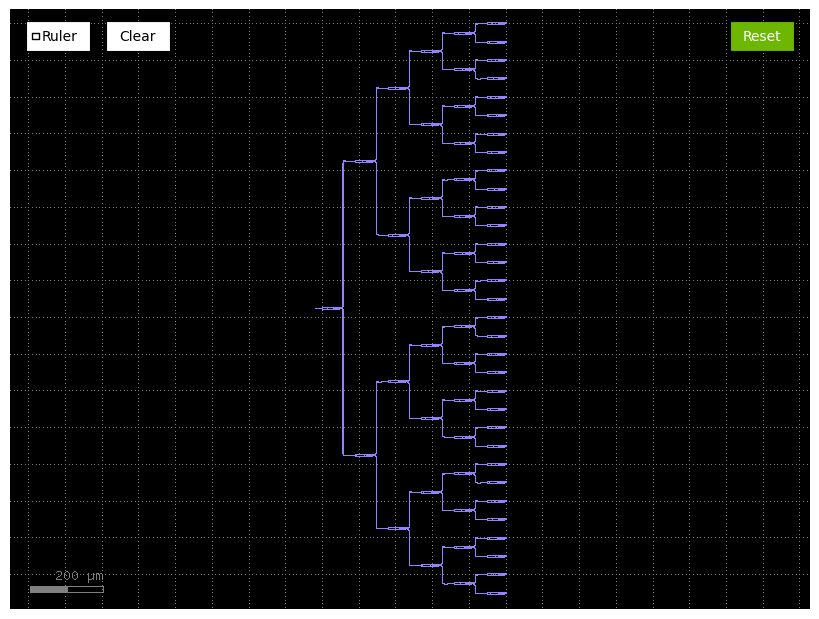

In [4]:
import gdsfactory as gf
import numpy as np
from axiomatic.pic_helpers import plot_circuit
import cspdk.si220.cband
cspdk.si220.cband.activate_pdk()

pdk = gf.get_active_pdk()
c = gf.Component()

def splitter_1xn(n_outputs: int, x_spacing: float = 90.0, y_spacing: float = 50.0) -> gf.Component:
    # Parameters
    depth = int(np.log2(n_outputs))

    c = gf.Component()
    mmi_refs = {}  # (level, index) -> reference

    # Place all MMIs in a symmetric binary tree layout
    for level in range(depth + 1):
        num_mmis = 2 ** level
        y_base = -(2 ** depth - 1) * y_spacing / 2
        for i in range(num_mmis):
            x = level * x_spacing
            y = y_base + (2 ** (depth - level)) * y_spacing * (i + 0.5)
            ref = c << pdk.get_component("mmi1x2")
            ref.name = f"mmi_{level}_{i}"
            ref.move((x, y))
            mmi_refs[(level, i)] = ref

    # Route MMIs from each level to the next
    for level in range(depth):
        for i in range(2 ** level):
            parent = mmi_refs[(level, i)]
            child_left = mmi_refs[(level + 1, 2 * i)]
            child_right = mmi_refs[(level + 1, 2 * i + 1)]

            gf.routing.route_single(c, port1=parent.ports["o3"], port2=child_left.ports["o1"],
                                    cross_section="strip", bend="bend_euler")
            gf.routing.route_single(c, port1=parent.ports["o2"], port2=child_right.ports["o1"],
                                    cross_section="strip", bend="bend_euler")

    # Add input port
    c.add_port("in0", port=mmi_refs[(0, 0)].ports["o1"])

    # Add output ports
    for i in range(2 ** depth):
        mmi = mmi_refs[(depth, i)]
        c.add_port(f"out{i * 2}", port=mmi.ports["o2"])
        c.add_port(f"out{i * 2 + 1}", port=mmi.ports["o3"])

    return c

# Example usage and plot
if __name__ == "__main__":
    c = splitter_1xn(n_outputs=32)
    plot_circuit(c)
